In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 64.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=1ab3fd58d6e79f6249133f96e111746cfd917f6f365ce36382d0e2b934bc4e46
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol without an attacker.



In [3]:
simulator = BasicSimulator()
MAX_QUBITS = 24   # hard limit of BasicSimulator

def quantum_random_bits(n: int) -> list:
    """
    Return n random bits by measuring 1/√2(|0⟩+|1⟩) states.
    Requests larger than MAX_QUBITS are split into chunks automatically.
    """
    bits = []
    remaining = n
    while remaining > 0:
        chunk = min(remaining, MAX_QUBITS)
        qc = QuantumCircuit(chunk, chunk)
        for i in range(chunk):
            qc.h(i)                        # |0⟩ → 1/√2(|0⟩ + |1⟩)
        qc.measure(range(chunk), range(chunk))
        job    = simulator.run(transpile(qc, simulator), shots=1)
        bitstr = list(job.result().get_counts().keys())[0]
        bits  += [int(b) for b in reversed(bitstr)]  # little-endian fix
        remaining -= chunk
    return bits[:n]

print(f"Quantum RNG ready (chunk size ≤ {MAX_QUBITS}).")
print("Sample 30 random bits:", quantum_random_bits(30))

Quantum RNG ready (chunk size ≤ 24).
Sample 30 random bits: [0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1]


In [4]:
N_QUBITS  = 100    # total qubits transmitted (any size — RNG handles chunking)
THRESHOLD = 0.15   # QBER above this → suspect eavesdropper

print(f"Transmitting {N_QUBITS} qubits | Error threshold = {THRESHOLD*100:.0f}%")

Transmitting 100 qubits | Error threshold = 15%


In [5]:
#Alice
alice_bits  = quantum_random_bits(N_QUBITS)  # secret bit values
alice_bases = quantum_random_bits(N_QUBITS)  # 0 = Z, 1 = X

def alice_encode(bit: int, basis: int) -> QuantumCircuit:
    """
    Encode one classical bit into a qubit state:
      Z-basis: |0⟩ (bit=0) or |1⟩ (bit=1)  — apply X gate for |1⟩
      X-basis: |+⟩ (bit=0) or |−⟩ (bit=1)  — apply H after optional X
    """
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)       # flip |0⟩ → |1⟩
    if basis == 1:
        qc.h(0)       # rotate to X-basis
    return qc

alice_circuits = [alice_encode(alice_bits[i], alice_bases[i])
                  for i in range(N_QUBITS)]

print(f"   Alice prepared {N_QUBITS} qubits.")
print(f"   First 10 bits : {alice_bits[:10]}")
print(f"   First 10 bases: {alice_bases[:10]}  (0=Z  1=X)")
print()
print("Example circuit — bit=1, X-basis (encodes |−⟩):")
print(alice_encode(1, 1))

   Alice prepared 100 qubits.
   First 10 bits : [0, 1, 1, 1, 0, 1, 0, 0, 0, 1]
   First 10 bases: [0, 0, 0, 0, 1, 0, 0, 1, 1, 0]  (0=Z  1=X)

Example circuit — bit=1, X-basis (encodes |−⟩):
     ┌───┐┌───┐
  q: ┤ X ├┤ H ├
     └───┘└───┘
c: 1/══════════
               


In [6]:
#bob
bob_bases = quantum_random_bits(N_QUBITS)

def bob_measure(alice_qc: QuantumCircuit, basis: int) -> int:
    """
    Measure in chosen basis:
      Z-basis: measure directly
      X-basis: apply H first to rotate back, then measure
    """
    qc = alice_qc.copy()
    if basis == 1:
        qc.h(0)
    qc.measure(0, 0)
    job = simulator.run(transpile(qc, simulator), shots=1)
    return int(list(job.result().get_counts().keys())[0])

bob_results = [bob_measure(alice_circuits[i], bob_bases[i])
               for i in range(N_QUBITS)]

print(f"   Bob measured {N_QUBITS} qubits.")
print(f"   First 10 bases  : {bob_bases[:10]}")
print(f"   First 10 results: {bob_results[:10]}")

   Bob measured 100 qubits.
   First 10 bases  : [1, 0, 0, 1, 1, 0, 0, 1, 0, 0]
   First 10 results: [0, 1, 1, 1, 0, 1, 0, 0, 1, 1]


In [7]:
#Alice + bob (basic reconciliation)
matching     = [i for i in range(N_QUBITS) if alice_bases[i] == bob_bases[i]]
sifted_alice = [alice_bits[i]  for i in matching]
sifted_bob   = [bob_results[i] for i in matching]

print(f"Total qubits       : {N_QUBITS}")
print(f"Matching bases     : {len(matching)}  ({len(matching)/N_QUBITS*100:.1f}%)")
print(f"Sifted key (Alice) : {''.join(map(str, sifted_alice[:20]))} ...")
print(f"Sifted key (Bob)   : {''.join(map(str, sifted_bob[:20]))} ...")

Total qubits       : 100
Matching bases     : 57  (57.0%)
Sifted key (Alice) : 11010010111110110001 ...
Sifted key (Bob)   : 11010010111110110001 ...


In [8]:
#QBER security check
half      = len(matching) // 2
check_idx = list(range(half))
key_idx   = list(range(half, len(matching)))

errors = sum(sifted_alice[i] != sifted_bob[i] for i in check_idx)
qber   = errors / len(check_idx) if check_idx else 0.0

print("─── Security Check ───────────────────────────────────")
print(f"Check bits    : {len(check_idx)}")
print(f"Errors found  : {errors}")
print(f"QBER          : {qber*100:.2f}%  (threshold = {THRESHOLD*100:.0f}%)")

if qber > THRESHOLD:
    print("\n  HIGH ERROR RATE — possible eavesdropper! Aborting.")
    final_key = final_key_bob = []
else:
    final_key     = [sifted_alice[i] for i in key_idx]
    final_key_bob = [sifted_bob[i]   for i in key_idx]
    print("\n Channel is secure — no attack detected.")
    print(f"\nShared key length : {len(final_key)} bits")
    print(f"Alice key sample  : {''.join(map(str, final_key[:20]))} ...")
    print(f"Bob   key sample  : {''.join(map(str, final_key_bob[:20]))} ...")
    print(f"Keys identical    : {final_key == final_key_bob}")

─── Security Check ───────────────────────────────────
Check bits    : 28
Errors found  : 0
QBER          : 0.00%  (threshold = 15%)

 Channel is secure — no attack detected.

Shared key length : 29 bits
Alice key sample  : 11010111010010100101 ...
Bob   key sample  : 11010111010010100101 ...
Keys identical    : True


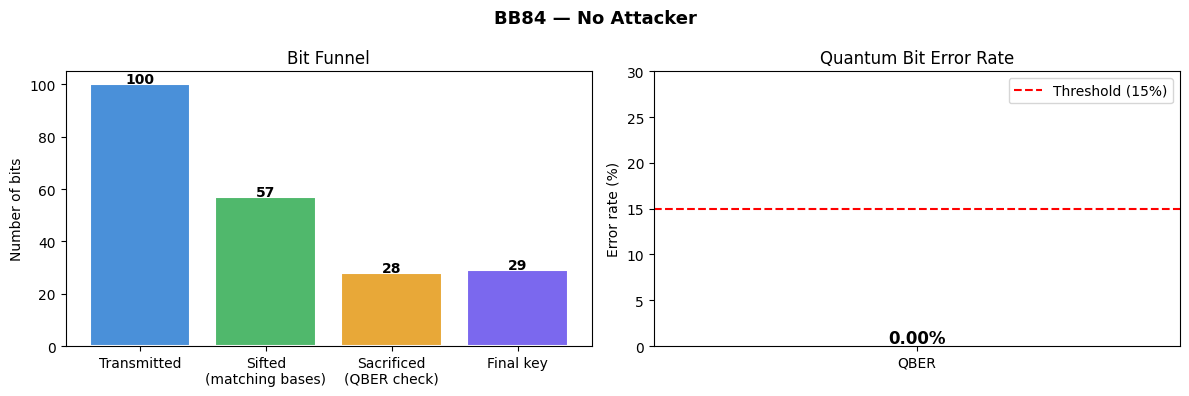


Measurement histogram — Alice encodes bit=0 in X-basis (|+⟩):


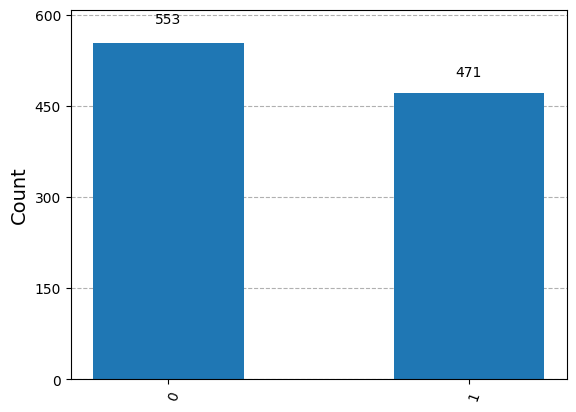

In [9]:
#Results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("BB84 — No Attacker", fontweight="bold", fontsize=13)

labels = ["Transmitted", "Sifted\n(matching bases)", "Sacrificed\n(QBER check)", "Final key"]
values = [N_QUBITS, len(matching), len(check_idx), len(final_key)]
colors = ["#4a90d9", "#50b86c", "#e8a838", "#7b68ee"]
axes[0].bar(labels, values, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Bit Funnel")
axes[0].set_ylabel("Number of bits")
for i, v in enumerate(values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontsize=10, fontweight="bold")

bar_col = "#50b86c" if qber <= THRESHOLD else "#d9534f"
axes[1].bar(["QBER"], [qber * 100], color=bar_col, width=0.35)
axes[1].axhline(THRESHOLD * 100, color="red", linestyle="--",
                label=f"Threshold ({THRESHOLD*100:.0f}%)")
axes[1].set_ylim(0, max(THRESHOLD * 200, 5))
axes[1].set_ylabel("Error rate (%)")
axes[1].set_title("Quantum Bit Error Rate")
axes[1].legend()
axes[1].text(0, qber * 100 + 0.3, f"{qber*100:.2f}%",
             ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

# Histogram: Alice encodes bit=0 in X-basis (|+⟩) — should give 50/50
print("\nMeasurement histogram — Alice encodes bit=0 in X-basis (|+⟩):")
qc_demo = alice_encode(0, 1)
qc_demo.measure(0, 0)
job_demo = simulator.run(transpile(qc_demo, simulator), shots=1024)
plot_histogram(job_demo.result().get_counts())